# Determinação de período de exoplaneta por velocidade radial

* PET - Física UFRN
* Petiano: José Emanuel Vasconcelos Oliveira
* Data: 26/06/2025

$\quad$ Nesse `Notebook`, queremos reproduzir os dados obtidos pelos vencedores do prêmio Nobel de Física de 2019, Michel Mayor e Didier Queloz. Os laureados identificaram e caracterizaram o primeiro exoplaneta orbitando uma estrela parecida com o sol, o 51 Pegasi b, em 1995 [1]. Aqui, utilizaremos os dados de velocidade radial dispostos na plataforma [DACE](https://dace.unige.ch/dashboard/), da Universidade de Genebra, e o periodograma Lomb-Scargle. Dessa forma, buscamos verificar se a utilização desse periodograma gera um valor de periodo orbital semelhante ao descoberto por Michel Mayor e Didier Queloz.

$\quad$ O `Notebook` seguirá a seguinte estrutura:

1. *Introdução*
2. *Velocidade Radial*
3. *Periodograma Lomb-Scargle*
4. *Determinação do período*
5. *Conclusão*

## Pré-requisitos

$\quad$ Os conhecimentos teóricos serão introduzidos de maneira suave ao correr do texto, de modo que não se faz necessário conhecimento prévio nos assuntos aqui discorridos.

$\quad$ Para que o leitor possa acompanhar os códigos desse `Notebook`, é necessário instalar a biblioteca `astropy`, que será base para extrairmos o periodograma utilizado. As demais bibliotecas estão inclusos na distribuição `Anaconda`. Para instalar a biblioteca `astropy`, basta digitar o comando `pip install astropy` em um terminal ou uma célula do `Jupiter Notebook` (nesse caso, inclua o sinal ! antes do comando).

## Importando bibliotecas

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import astropy.timeseries as astro
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u
from scipy.optimize import curve_fit
import lightkurve as lk
from pathlib import Path

C:\Users\emanu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Detalhes das bibliotecas

In [2]:
%load_ext version_information
%version_information matplotlib, numpy, pandas, scipy, astropy

C:\Users\emanu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\version_information\version_information.py:60: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Software versions
Python 3.14.2 64bit [MSC v.1944 64 bit (AMD64)]
IPython 9.8.0
OS Windows 11 10.0.26200 SP0
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
scipy 1.16.3
astropy 7.2.0
Tue Mar 03 23:24:57 2026 Hora Padrão de Buenos Aires

## Introdução

falar sobre como a humanidade busca por vida fora da terra e conhecer a evolução de sistemas planetarios -> exoplanetas -> caracterização, buscando conhecer a evolução
tecnicas -> fotometria e espectroscopia -> velocidade radial e transito
periodo -> revela informações importantes sobre dados do planeta -> terceira lei de kepler

## Velocidade Radial

lei da gravitação universal de newton -> 3 lei de Newton
orbita em torno do centro de massa do sistema estrela-planeta
explicação mecanica
efeito doppler da luz -> espectroscopia de emissão -> determinação da velocidade radial

## Periodograma Lomb-Scargle

periodograma e minimos quadrados
contas infinitas
vantagens de se utilizar 

USAR PLANETA HD 209458

## Determinação do período

In [ ]:
TOI = 'TIC 364186197'
search_result = lk.search_lightcurve(TOI, mission = 'Tess') 
# Como queremos trabalhar apenas com dados da missão TESS, restringimos a busca das curvas de luz.
search_result

In [2]:
# 1. Configurações de Astronomia
target = SkyCoord("22h03m10.77s", "+18d53m03.5s", frame='icrs')

mapa_sites = {
    'COR': 'La Silla Observatory',
    'ELODIE': 'Observatoire de Haute Provence', # Ajustado aqui
    'ESPR19': 'Paranal Observatory',
    'HAMILTON': 'Lick Observatory',
    'HARPS03': 'La Silla Observatory',
    'HIRES': 'Keck Observatory',
    'HIRES-post04': 'Keck Observatory',
    'HIRES-pre04': 'Keck Observatory'
}

# 2. Leitura dos Arquivos
pasta = Path('HD209458_timeseries')
arquivos = list(pasta.glob("*.rdb"))

dfs = []
dfs_desl = []

for arq in arquivos:
    # O DACE usa .rdb que é TSV (tab-separated)
    df = pd.read_csv(arq, sep="\t", skiprows=[1])
    
    # Extrair o nome do instrumento do arquivo (ex: HD209458_HIRES_Pub-2005.rdb)
    # Pegamos a segunda parte após o primeiro '_'
    nome_inst = arq.stem.split('_')[1]
    site_name = mapa_sites.get(nome_inst, 'Greenwich')
    
    # --- CÁLCULO DA BJD ---
    # 1. Converter RJD para JD total
    # O DACE usa RJD = JD - 2400000.0
    jd_total = df['rjd'] + 2400000.0
    
    # 2. Definir a localização para este arquivo específico
    location = EarthLocation.of_site(site_name)
    
    # 3. Criar o objeto Time (escala UTC é o padrão para JD bruto)
    t = Time(jd_total, format='jd', scale='utc', location=location)
    
    # 4. Calcular a correção de tempo (Light Travel Time) até o Baricentro
    ltt_bary = t.light_travel_time(target)
    
    # 5. Adicionar a coluna BJD (usando escala TDB, que é o padrão científico)
    df['bjd'] = (t.tdb + ltt_bary).value - 2450000
    # -----------------------

    # Guardar qual instrumento gerou esse dado (importante para o ajuste final)
    df['instrumento'] = nome_inst

    # Seu filtro original
    if df["vrad"].mean() > -2000:
        dfs.append(df)
    else:
        dfs_desl.append(df)

# Se quiser unir todos os válidos em um único DataFrame:
df_final = pd.concat(dfs, ignore_index=True)

In [3]:
media = df_final["vrad"].mean()
dfs_convertidos = []

for df in dfs_desl:
    media_desl = df["vrad"].mean()
    df["vrad"] = df["vrad"] - media_desl + media
    dfs_convertidos.append(df)

df = pd.concat([df_final] + dfs_convertidos, ignore_index = True)

In [4]:
# Mostra as primeiras linhas para conferir a diferença entre RJD e BJD
print(df[['instrumento', 'rjd', 'bjd']].head())

  instrumento          rjd          bjd
0    HAMILTON  51733.81445  1733.818205
1    HAMILTON  51733.82324  1733.826996
2    HAMILTON  51733.83398  1733.837737
3    HAMILTON  51733.84277  1733.846527
4    HAMILTON  51733.85059  1733.854348


In [5]:
df_final = df.sort_values(by='bjd').reset_index(drop=True)
colunas = ['instrumento', 'bjd', 'vrad', 'svrad'] # Exemplo de colunas do DACE
df_final[colunas].to_csv('dados_limpos.csv', index=False)

In [22]:
vrad = df_final["vrad"]
bjd = df_final["bjd"]
erro_vrad = df_final["svrad"]

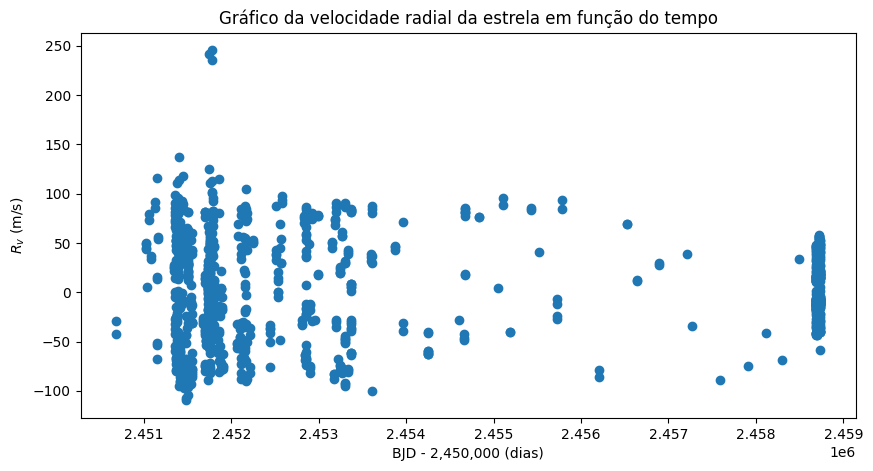

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(bjd,vrad,'o')
plt.ylabel("$R_v$ (m/s)")
plt.xlabel("BJD - 2,450,000 (dias)")
plt.title("Gráfico da velocidade radial da estrela em função do tempo")
plt.show()

In [24]:
ls = astro.LombScargle(bjd,vrad,erro_vrad)
frequencies, power = ls.autopower(
    minimum_frequency = 1/30,
    maximum_frequency = 1/0.5,
    samples_per_peak = 20
)

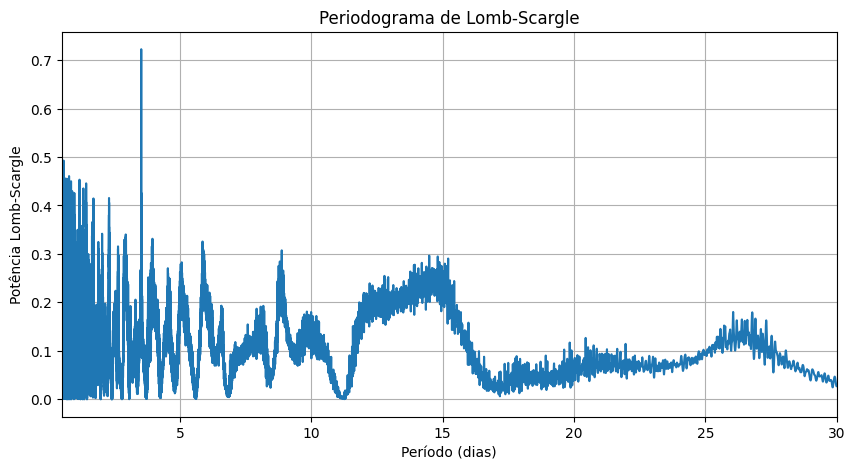

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(1/frequencies, power)
plt.xlabel("Período (dias)")
plt.ylabel("Potência Lomb-Scargle")
plt.title("Periodograma de Lomb-Scargle")
plt.xlim(0.5,30)
plt.grid(True)
plt.show()

In [26]:
frequencia_pico = frequencies[np.argmax(power)]
periodo_dominante= 1 / frequencia_pico;
periodo_dominante

np.float64(3.5247337942927586)

In [27]:
T = bjd.max() - bjd.min()
df = 1/T
dp = df*(periodo_dominante**2)/2;dp

np.float64(0.0007709449911449831)

In [28]:
print(f"Período = {periodo_dominante:.5f} ± {dp:.5f} dias")

Período = 3.52473 ± 0.00077 dias


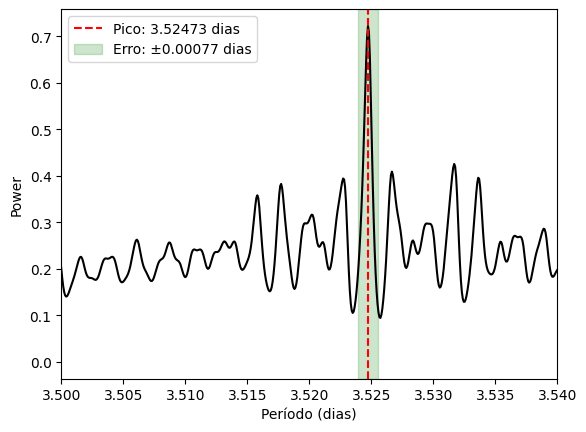

In [29]:
plt.plot(1 / frequencies, power, 'k-')
plt.axvline(periodo_dominante, color='r', linestyle='--',
            label=f'Pico: {periodo_dominante:.5f} dias')
plt.axvspan(periodo_dominante - dp, periodo_dominante + dp, alpha=0.2, color='g',
            label=f'Erro: ±{dp:.5f} dias')
plt.xlabel('Período (dias)')
plt.xlim(3.50, 3.54)
plt.ylabel('Power')
plt.legend()
plt.show()

C:\Users\emanu\AppData\Local\Temp\ipykernel_10212\1465777115.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  param_opt, cov = curve_fit(modelo_seno, bjd, vrad, p0=param_inicial, sigma=erro_vrad, absolute_sigma=True)


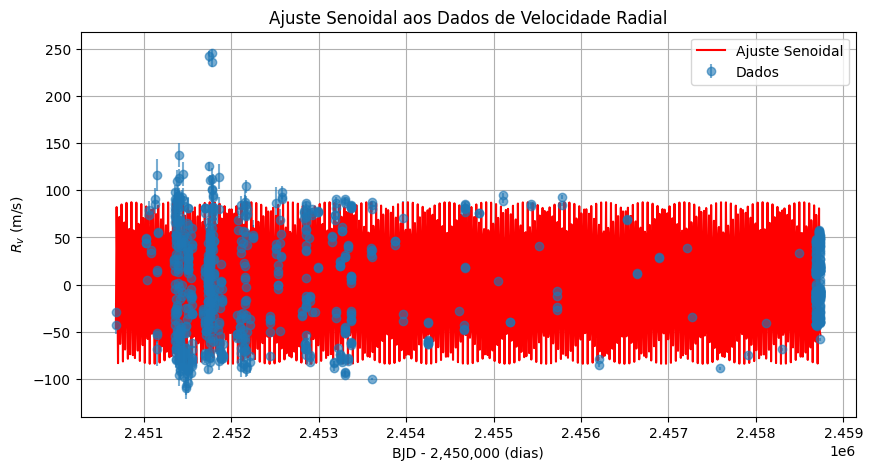

In [30]:
# Define a função senoidal
def modelo_seno(t, A, omega, phi, offset):
    return A * np.sin(omega * t + phi) + offset

# Estimativas iniciais
A_inicial = (np.max(vrad) - np.min(vrad)) / 2
omega_inicial = 2 * np.pi / periodo_dominante
phi_inicial = 0
offset_inicial = np.mean(vrad)
param_inicial = [A_inicial, omega_inicial, phi_inicial, offset_inicial]

# Ajuste da curva
param_opt, cov = curve_fit(modelo_seno, bjd, vrad, p0=param_inicial, sigma=erro_vrad, absolute_sigma=True)

A_fit, omega_fit, phi_fit, offset_fit = param_opt
# Recria o modelo ajustado
t_fit = np.linspace(min(bjd), max(bjd), 1000)
vrad_fit = modelo_seno(t_fit, *param_opt)

# Plot do ajuste
plt.figure(figsize=(10, 5))
plt.errorbar(bjd, vrad, yerr=erro_vrad, fmt='o', label='Dados', alpha=0.6)
plt.plot(t_fit, vrad_fit, label='Ajuste Senoidal', color='red')
plt.ylabel("$R_v$ (m/s)")
plt.xlabel("BJD - 2,450,000 (dias)")
plt.title('Ajuste Senoidal aos Dados de Velocidade Radial')
plt.legend()
plt.grid(True)
plt.show()

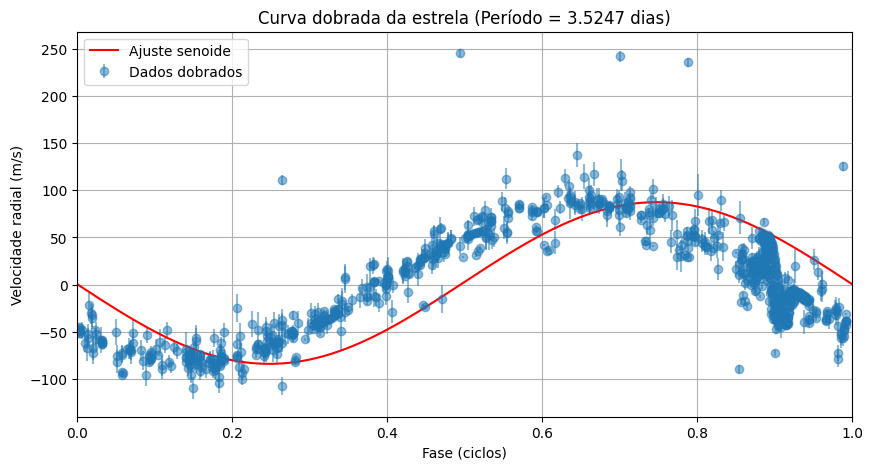

In [31]:
periodo_ajustado = 2*np.pi/omega_fit
# Converte tempo para fase normalizada (0 a 1)
fase = (bjd % periodo_dominante) / periodo_dominante

# Gera curva seno ajustada ao longo de 2 ciclos
fase_fit = np.linspace(0, 1, 1000)
t_fit_fold = fase_fit * periodo_ajustado
vrad_fit_fold = modelo_seno(t_fit_fold, *param_opt)

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(fase, vrad, yerr=erro_vrad, fmt='o', alpha=0.5, label='Dados dobrados')
plt.plot(fase_fit, vrad_fit_fold, color='red', label='Ajuste senoide')
plt.xlabel("Fase (ciclos)")
plt.ylabel("Velocidade radial (m/s)")
plt.title(f"Curva dobrada da estrela (Período = {periodo_ajustado:.4f} dias)")
plt.xlim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Conclusão

## Referências

[1] Mayor, M. and Queloz, D.; 1995. *Nature* 378, 355.

[6] Scargle, J.; 1982. *The Astrophysical Journal*, 263, 835.

[7] Lomb, N.R.; 1976. *Astrophysics and Space Science*, 39, 447.